In [1]:
from src.data.loader import process_protonated_files, create_data
from src.preprocessing.interpolation import resample_trajectory
from src.preprocessing.atom_process import get_ca_coordinates
from src.preprocessing.curves import get_invariant_features

from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from src.data.dataset import Trajectories_dataset
from src.models.vae import ConvVAE
from src.metrics.vae_loss import vae_loss
import torch.optim as optim
import torch
import torch.nn.functional as F
import warnings
import os

warnings.filterwarnings('ignore')

from src.utils.config_loader import project_config
import torch



config = project_config.load()  # загружает configs/config.yaml
print(f"\n Основная информация:")
print(f"   Проект: {config.get('project', {}).get('name', 'N/A')}")
print(f"   Версия: {config.get('project', {}).get('version', 'N/A')}")
print(f"   Автор: {config.get('project', {}).get('author', 'N/A')}")
print(f"   Будет обработано: {config.get('dataset', {}).get('length', 1000)} примеров")
print(f"   Обучение будет происходить: {config.get('model', {}).get('device', 'cpu')}")
print(f"   Размеры примеров(в атомах): от {config.get('dataset', {}).get('min_atom_len', 1)} до {config.get('dataset', {}).get('max_atom_len', 1000)} ")







JSON_DATA = process_protonated_files('data/by_pairs_dataset', max_l = config.get('dataset', {}).get('length', 1000), alpha=config.get('dataset', {}).get('min_atom_len', 1), beta=config.get('dataset', {}).get('max_atom_len', 1000))
trace_data, graph_data, ca_coordinate_data = create_data(JSON_DATA, K = 1024)
print(ca_coordinate_data[0])

train_data_raw, val_data_raw = train_test_split(
    trace_data,       
    test_size=config.get('training', {}).get('validation_split', 0.1),  
    random_state=42 
)


device = config.get('model', {}).get('cuda', 'cpu')
learning_rate = config.get('training', {}).get('learning_rate', 0.1)
num_epochs = config.get('training', {}).get('epochs', 100)
batch_size = config.get('training', {}).get('batch_size', 16)


 Основная информация:
   Проект: vectoratomcurves
   Версия: 1.0.0
   Автор: Polyakov Stepan
   Будет обработано: 4000 примеров
   Обучение будет происходить: cuda
   Размеры примеров(в атомах): от 500 до 5000 
Начало подготовки. Загрузка файлов
Найдено 5474 protonated файлов


Обработка файлов:  40%|███████████████████████████████████████████████████████████████████████▏                                                                                                          | 2189/5474 [00:20<00:25, 130.45it/s]

Не все файлы существуют для data/by_pairs_dataset/8kge/V_chain.protonated.json
Отсутствуют файлы: ['charges']


Обработка файлов: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5474/5474 [00:50<00:00, 107.35it/s]


Успешно обработано 3657 файлов
Не прошли критериев 1816 молекул
Начало расчета координат


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3657/3657 [00:28<00:00, 128.42it/s]

Successful!
[(21.685, -65.344, -18.414), (20.307, -62.817, -15.96), (21.034, -59.105, -16.403), (20.048, -56.113, -14.331), (19.476, -52.648, -15.709), (19.486, -49.566, -13.535), (20.195, -45.844, -13.247), (22.517, -44.898, -10.352), (23.542, -41.519, -8.972), (27.106, -40.858, -8.096), (26.829, -40.146, -4.283), (23.938, -42.335, -3.454), (22.73, -43.404, -0.007), (21.821, -47.01, -0.369), (18.847, -48.316, 1.537), (16.412, -51.173, 0.874), (14.602, -49.662, -2.062), (17.829, -48.797, -3.999), (19.984, -50.736, -6.4), (22.419, -52.719, -4.112), (25.907, -51.828, -3.291), (27.83, -53.892, -5.881), (31.436, -54.926, -5.5), (33.448, -53.252, -8.256), (36.169, -55.948, -7.941), (33.696, -58.538, -9.199), (32.587, -56.772, -12.419), (34.502, -56.126, -15.687), (33.62, -53.008, -17.576), (33.075, -53.991, -21.166), (31.451, -50.872, -22.587), (31.484, -47.213, -21.435), (29.978, -44.289, -23.348), (30.293, -40.787, -21.851), (28.015, -37.989, -23.007), (27.01, -34.406, -22.261), (24.629, 

In [2]:
from src.models.ae import ConvAutoencoder

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DilatedResidualBlock(nn.Module):
    def __init__(self, channels, dilation, kernel_size=3):
        super(DilatedResidualBlock, self).__init__()
        padding = dilation * (kernel_size - 1) // 2
        
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, 
                      padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.ReLU(True),
            nn.Conv1d(channels, channels, kernel_size=1), # 1x1 свертка для перемешивания
            nn.BatchNorm1d(channels)
        )
        self.relu = nn.ReLU(True)

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out += residual # Проброс градиента
        return self.relu(out)

class DilConv(nn.Module):
    def __init__(self, input_channels=3, sequence_length=1024, latent_dim=256, dropout_rate=0.05):
        super(DilConv, self).__init__()
        
        self.initial_conv = nn.Conv1d(input_channels, 32, kernel_size=7, padding=3)
        
        self.enc_layers = nn.ModuleList([
            DilatedResidualBlock(32, dilation=1),
            nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1), # 1024 -> 512
            
            DilatedResidualBlock(64, dilation=2),
            nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1), # 512 -> 256
            
            DilatedResidualBlock(128, dilation=4),
            nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1), # 256 -> 128
            
            DilatedResidualBlock(256, dilation=8),
            nn.Conv1d(256, 512, kernel_size=4, stride=2, padding=1), # 128 -> 64
            
            DilatedResidualBlock(512, dilation=16),
            nn.Conv1d(512, 512, kernel_size=4, stride=2, padding=1), # 64 -> 32
        ])
        
        self.final_length = sequence_length // (2**5) 
        self.encoded_size = 512 * self.final_length 
        
        self.latent_layer = nn.Linear(self.encoded_size, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, self.encoded_size)

        self.dec_layers = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), # 32 -> 64
            nn.Conv1d(512, 512, kernel_size=3, padding=1),
            DilatedResidualBlock(512, dilation=8),
            
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), # 64 -> 128
            nn.Conv1d(512, 256, kernel_size=3, padding=1),
            DilatedResidualBlock(256, dilation=4),
            
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), # 128 -> 256
            nn.Conv1d(256, 128, kernel_size=3, padding=1),
            DilatedResidualBlock(128, dilation=2),
            
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), # 256 -> 512
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            DilatedResidualBlock(64, dilation=1),
            
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), # 512 -> 1024
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
        ])
        
        self.final_out = nn.Sequential(
            nn.Conv1d(32, input_channels, kernel_size=3, padding=1),
            nn.Sigmoid() # Оставляем, если данные в [0, 1]
        )

    def encode(self, x):
        x = self.initial_conv(x)
        for layer in self.enc_layers:
            x = layer(x)
        x = x.view(x.size(0), -1)
        return self.latent_layer(x)

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(x.size(0), 512, self.final_length)
        for layer in self.dec_layers:
            x = layer(x)
        return self.final_out(x)

    def forward(self, x):
        # x shape: [batch, seq_len, 3] -> transpose to [batch, 3, seq_len]
        x = x.transpose(1, 2)
        
        latent = self.encode(x)
        reconstructed = self.decode(latent)
        
        # back to [batch, seq_len, 3]
        return reconstructed.transpose(1, 2), latent

def compute_loss(reconstructed, target):
    mse_loss = F.mse_loss(reconstructed, target)
    v_reconstructed = reconstructed[:, 1:, :] - reconstructed[:, :-1, :]
    v_target = target[:, 1:, :] - target[:, :-1, :]
    velocity_loss = F.mse_loss(v_reconstructed, v_target)
    
    return mse_loss + 0.5 * velocity_loss

In [20]:
train_dataset = Trajectories_dataset(train_data_raw, normalize=True)
val_dataset = Trajectories_dataset(val_data_raw, normalize=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
model = DilConv(sequence_length = 1024, latent_dim = 256).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [21]:
def loss(reconstructed, target):
    mse_loss = F.mse_loss(reconstructed, target)
    
    # Считаем разницу между соседними точками (скорость/направление)
    diff_reconstructed = reconstructed[:, 1:, :] - reconstructed[:, :-1, :]
    diff_target = target[:, 1:, :] - target[:, :-1, :]
    velocity_loss = F.mse_loss(diff_reconstructed, diff_target)
    
    return mse_loss + velocity_loss # Коэффициент можно подбирать

In [22]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

# Инициализация списков для лоссов
train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []

print('Начало обучения автокодировщика')

patience = 15 # Количество эпох ожидания улучшения
best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(num_epochs):
    # Обучение
    model.train()
    train_total_loss = 0
    train_recon_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
    
    for batch in train_bar:
        signals = batch[0].to(device)
        
        # Прямой проход через модель
        reconstructed, latent = model(signals)
        
        # Вычисление функции потерь
        recon_loss = compute_loss(reconstructed, signals)
        total_loss = recon_loss
        
        # Обратное распространение
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Суммирование лоссов
        train_total_loss += total_loss.item()
        train_recon_loss += recon_loss.item()
        
        # Обновление прогресс-бара
        train_bar.set_postfix({'Loss': f'{total_loss.item():.4f}'})
    
    # Валидация
    model.eval()
    val_total_loss = 0
    val_recon_loss = 0
    
    val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False)
    
    with torch.no_grad():
        for batch in val_bar:
            signals = batch[0].to(device)
            
            # Прямой проход
            reconstructed, latent = model(signals)
            
            # Вычисление потерь
            recon_loss = F.mse_loss(reconstructed, signals, reduction='mean')
            total_loss = recon_loss
            
            # Суммирование
            val_total_loss += total_loss.item()
            val_recon_loss += recon_loss.item()
            
            # Обновление прогресс-бара
            val_bar.set_postfix({'Loss': f'{total_loss.item():.4f}'})
    
    # Усреднение лоссов
    avg_train_total = train_total_loss / len(train_loader)
    avg_train_recon = train_recon_loss / len(train_loader)
    
    avg_val_total = val_total_loss / len(val_loader)
    avg_val_recon = val_recon_loss / len(val_loader)
    
    # Сохранение лоссов для графиков
    train_losses.append(avg_train_total)
    val_losses.append(avg_val_total)
    train_recon_losses.append(avg_train_recon)
    val_recon_losses.append(avg_val_recon)
    
    # Вывод информации об эпохе
    print(f'\nEpoch [{epoch+1}/{num_epochs}]')
    print(f'  Train - Loss: {avg_train_total:.6f} | Recon: {avg_train_recon:.6f}')
    print(f'  Val   - Loss: {avg_val_total:.6f} | Recon: {avg_val_recon:.6f}')
    
    # Проверка улучшения валидационного лосса
    is_best = avg_val_total < best_val_loss
    improvement = best_val_loss - avg_val_total
    
    if is_best:
        best_val_loss = avg_val_total
        epochs_without_improvement = 0
        
        # Сохранение лучшей модели
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_total,
            'val_loss': avg_val_total,
            'best_val_loss': best_val_loss,
        }, 'best_autoencoder.pth')
        print(f'  ✓ Сохранена лучшая модель (val loss: {avg_val_total:.6f}, улучшение: {improvement:.6f})')
    else:
        epochs_without_improvement += 1
        print(f'  Вариация: {improvement:.6f} (без улучшения: {epochs_without_improvement}/{patience})')
    
    # Ранняя остановка
    if epochs_without_improvement >= patience:
        print(f'  ⏹ Ранняя остановка после {epoch+1} эпох')
        print(f'     Лучший val loss: {best_val_loss:.6f}')
        break
    
    # Проверка на NaN
    if torch.isnan(torch.tensor(avg_val_total)):
        print('  ⚠ Обнаружен NaN в лоссе, остановка обучения')
        break
    
    print('-' * 80)

print(f'\nОбучение завершено за {epoch+1} эпох!')
print(f'Лучший валидационный loss: {best_val_loss:.6f}')

Начало обучения автокодировщика



Epoch [1/200]
  Train - Loss: 0.027237 | Recon: 0.027237
  Val   - Loss: 0.016489 | Recon: 0.016489
  ✓ Сохранена лучшая модель (val loss: 0.016489, улучшение: inf)
--------------------------------------------------------------------------------



Epoch [2/200]
  Train - Loss: 0.011382 | Recon: 0.011382
  Val   - Loss: 0.011212 | Recon: 0.011212
  ✓ Сохранена лучшая модель (val loss: 0.011212, улучшение: 0.005277)
--------------------------------------------------------------------------------



Epoch [3/200]
  Train - Loss: 0.007831 | Recon: 0.007831
  Val   - Loss: 0.008062 | Recon: 0.008062
  ✓ Сохранена лучшая модель (val loss: 0.008062, улучшение: 0.003150)
--------------------------------------------------------------------------------



Epoch [4/200]
  Train - Loss: 0.005849 | Recon: 0.005849
  Val   - Loss: 0.006216 | Recon: 0.006216
  ✓ Сохранена лучшая модель (val loss: 0.006216, улучшение: 0.001846)
--------------------------------------------------------------------------------


...


Epoch [74/200]
  Train - Loss: 0.000687 | Recon: 0.000687
  Val   - Loss: 0.001341 | Recon: 0.001341
  Вариация: -0.000250 (без улучшения: 11/15)
--------------------------------------------------------------------------------



Epoch [75/200]
  Train - Loss: 0.000652 | Recon: 0.000652
  Val   - Loss: 0.001245 | Recon: 0.001245
  Вариация: -0.000153 (без улучшения: 12/15)
--------------------------------------------------------------------------------



Epoch [76/200]
  Train - Loss: 0.000646 | Recon: 0.000646
  Val   - Loss: 0.001285 | Recon: 0.001285
  Вариация: -0.000194 (без улучшения: 13/15)
--------------------------------------------------------------------------------



Epoch [77/200]
  Train - Loss: 0.000611 | Recon: 0.000611
  Val   - Loss: 0.001118 | Recon: 0.001118
  Вариация: -0.000026 (без улучшения: 14/15)
--------------------------------------------------------------------------------



Epoch [78/200]
  Train - Loss: 0.000688 | Recon: 0.000688
  Val   - Loss: 0.001149 | Recon: 0.001149
  Вариация: -0.000058 (без улучшения: 15/15)
  ⏹ Ранняя остановка после 78 эпох
     Лучший val loss: 0.001092

Обучение завершено за 78 эпох!
Лучший валидационный loss: 0.001092


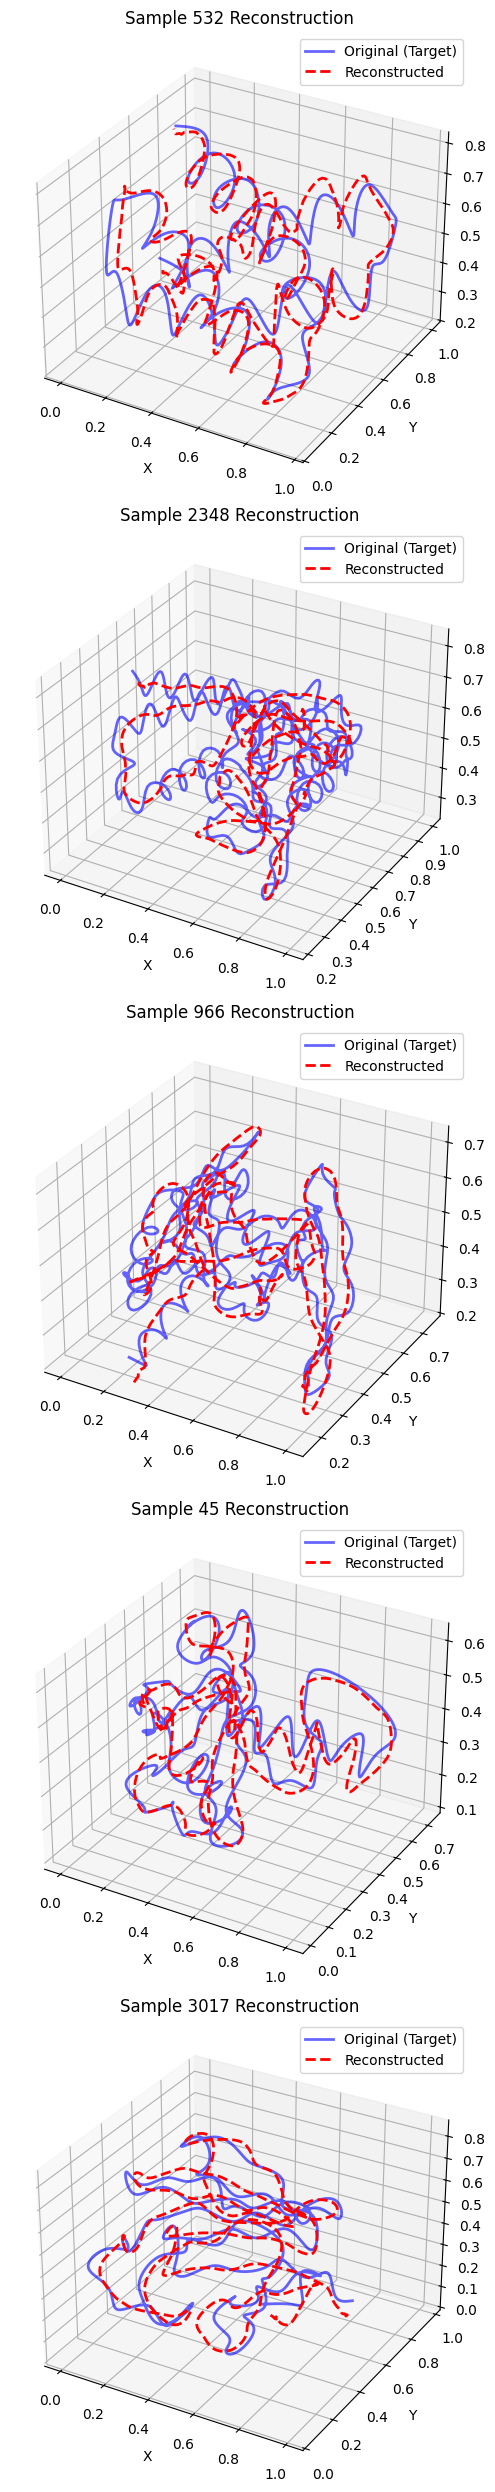

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_reconstruction(model, dataset, num_samples=3, device='cpu'):
    model.eval()
    model.to(device)
    
    # Выбираем случайные индексы
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig = plt.figure(figsize=(15, 5 * num_samples))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Получаем данные из датасета
            # dataset[idx] возвращает (input, target)
            original_input, target_curve = dataset[idx]
            
            # Подготовка для модели (добавляем размер батча)
            input_tensor = original_input.unsqueeze(0).to(device)
            
            # Проход через VAE
            # На выходе: (реконструкция, mu, logvar)
            reconstructed_curve, latent = model(input_tensor)
            
            # Переводим в numpy для отрисовки
            orig = target_curve.cpu().numpy() # Оригинал (целевой)
            recon = reconstructed_curve.squeeze(0).cpu().numpy() # Восстановленный

            # Отрисовка 3D
            ax = fig.add_subplot(num_samples, 1, i + 1, projection='3d')
            
            # Рисуем оригинал
            ax.plot(orig[:, 0], orig[:, 1], orig[:, 2], label='Original (Target)', color='blue', alpha=0.6, lw=2)
            
            # Рисуем реконструкцию
            ax.plot(recon[:, 0], recon[:, 1], recon[:, 2], label='Reconstructed', color='red', linestyle='--', lw=2)
            
            ax.set_title(f"Sample {idx} Reconstruction")
            ax.legend()
            
            # Настройка осей для красоты
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()

# Использование:
visualize_reconstruction(model, train_dataset, num_samples=5, device=device)